# 03 — Label Integrity Check

> **Goal:** Deep-dive into the cleaned dataset's labels to detect structural issues that go beyond basic format validation.

**Checks performed:**
1. Images without matching label files (orphan images)
2. Label files without matching images (orphan labels)
3. Empty label files (background / negative images — flagged but kept)
4. Per-class annotation count and imbalance analysis
5. Bounding-box size distribution (tiny / huge boxes)
6. Overlapping / near-duplicate bounding boxes within the same image
7. Images with unusually high annotation counts (possible labelling errors)

**Input:** `dataset_cleaned/` (output of NB02)  
**Output:** `logs/03_integrity_report_<timestamp>.json`  
**Fixes applied:** Orphan labels are deleted; summary written to log.

In [2]:
import subprocess, sys
for pkg in [('cv2','opencv-python'),('yaml','pyyaml'),('tqdm','tqdm'),
            ('seaborn','seaborn'),('numpy','numpy'),('matplotlib','matplotlib')]:
    try:
        __import__(pkg[0])
    except ImportError:
        subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', pkg[1]])
print('Packages OK.')

Packages OK.


In [3]:
import os
import cv2
import json
import yaml
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from pathlib import Path
from datetime import datetime
from collections import Counter
import warnings

warnings.filterwarnings('ignore')
try:
    from tqdm.notebook import tqdm
except ImportError:
    from tqdm import tqdm

try:
    plt.style.use('seaborn-v0_8-whitegrid')
except OSError:
    plt.style.use('ggplot')

print('Imports complete.')

Imports complete.


## Configuration

In [4]:
# Use cleaned dataset; fall back to raw if cleaning hasn't run yet
CLEANED_DIR = Path('dataset_cleaned')
RAW_DIR     = Path('DATA_AFTER MERGED')
DATASET_DIR = CLEANED_DIR if CLEANED_DIR.exists() else RAW_DIR

LOG_DIR   = Path('logs')
LOG_DIR.mkdir(exist_ok=True)
TIMESTAMP = datetime.now().strftime('%Y%m%d_%H%M%S')
SPLITS    = ['train', 'valid', 'test']

yaml_candidates = [
    DATASET_DIR / 'data.yaml',
    RAW_DIR     / 'data.yaml',
]
yaml_path = next((p for p in yaml_candidates if p.exists()), None)
assert yaml_path, 'data.yaml not found'

with open(yaml_path) as f:
    data_yaml = yaml.safe_load(f)
CLASS_NAMES = data_yaml['names']
NUM_CLASSES = len(CLASS_NAMES)

print(f'Dataset dir   : {DATASET_DIR.resolve()}')
print(f'Classes ({NUM_CLASSES})   : {CLASS_NAMES}')

Dataset dir   : C:\Users\shaho\OneDrive\Desktop\grad\dataset_cleaned
Classes (6)   : ['Customer-Bagpack', 'Product', 'Product-Picked', 'Shopping-Cart', 'normal', 'theft']


## Scan Labels

In [6]:
from tqdm import tqdm
IMG_EXTS = ('*.jpg','*.jpeg','*.png','*.JPG','*.JPEG','*.PNG','*.bmp','*.BMP')

orphan_images  = []   # image with no label
orphan_labels  = []   # label with no image
empty_labels   = []   # label file that is empty (background)
high_ann_count = []   # images with > threshold annotations

global_class_counts = Counter()
all_bbox_widths  = []
all_bbox_heights = []
all_bbox_areas   = []
per_image_ann_counts = []
HIGH_ANN_THRESHOLD = 30   # flag images with more than this many boxes

split_integrity = {}

for split in SPLITS:
    img_dir = DATASET_DIR / split / 'images'
    lbl_dir = DATASET_DIR / split / 'labels'

    if not img_dir.exists():
        print(f'WARNING: {img_dir} not found — skipping.')
        continue

    # Collect stems
    img_stems = set()
    for ext in IMG_EXTS:
        for p in img_dir.glob(ext):
            img_stems.add(p.stem)

    lbl_stems = {p.stem for p in lbl_dir.glob('*.txt')} if lbl_dir.exists() else set()

    only_img = img_stems - lbl_stems   # images without labels
    only_lbl = lbl_stems - img_stems   # labels without images

    for stem in only_img:
        orphan_images.append({'split': split, 'stem': stem})
    for stem in only_lbl:
        orphan_labels.append({'split': split, 'stem': stem})

    # Deep annotation scan for matched pairs
    matched_stems = img_stems & lbl_stems
    ann_counts_split = []
    empty_split = 0
    class_cnt_split = Counter()

    print(f'\n[{split.upper()}] {len(img_stems)} images | {len(lbl_stems)} labels | {len(matched_stems)} matched')

    for stem in tqdm(sorted(matched_stems), desc=f'  {split}', unit='pair'):
        lbl_path = lbl_dir / f'{stem}.txt'

        if lbl_path.stat().st_size == 0:
            empty_split += 1
            empty_labels.append({'split': split, 'stem': stem})
            per_image_ann_counts.append(0)
            ann_counts_split.append(0)
            continue

        try:
            lines = lbl_path.read_text(encoding='utf-8', errors='replace').strip().splitlines()
        except Exception:
            continue

        ann_count = 0
        for raw in lines:
            parts = raw.strip().split()
            if len(parts) != 5:
                continue
            try:
                cls_id = int(float(parts[0]))
                xc, yc, bw, bh = (float(p) for p in parts[1:])
            except ValueError:
                continue
            if not (0 <= cls_id < NUM_CLASSES):
                continue
            if not (0 < bw <= 1 and 0 < bh <= 1):
                continue

            global_class_counts[cls_id] += 1
            class_cnt_split[cls_id] += 1
            all_bbox_widths.append(bw)
            all_bbox_heights.append(bh)
            all_bbox_areas.append(bw * bh)
            ann_count += 1

        per_image_ann_counts.append(ann_count)
        ann_counts_split.append(ann_count)

        if ann_count > HIGH_ANN_THRESHOLD:
            high_ann_count.append({'split': split, 'stem': stem, 'count': ann_count})

    split_integrity[split] = {
        'total_images':    len(img_stems),
        'total_labels':    len(lbl_stems),
        'matched':         len(matched_stems),
        'orphan_images':   len(only_img),
        'orphan_labels':   len(only_lbl),
        'empty_labels':    empty_split,
        'class_counts':    dict(class_cnt_split),
        'avg_ann_per_img': float(np.mean(ann_counts_split)) if ann_counts_split else 0.0,
    }

print('\nScan complete.')


[TRAIN] 8569 images | 8569 labels | 8569 matched


  train: 100%|██████████| 8569/8569 [00:01<00:00, 5987.25pair/s]



[VALID] 1526 images | 1526 labels | 1526 matched


  valid: 100%|██████████| 1526/1526 [00:00<00:00, 6506.07pair/s]



[TEST] 740 images | 740 labels | 740 matched


  test: 100%|██████████| 740/740 [00:00<00:00, 5810.54pair/s]


Scan complete.


## Fix Orphan Labels

In [7]:
# Remove label files that have no matching image
removed_orphan_labels = []
for item in orphan_labels:
    lbl_dir = DATASET_DIR / item['split'] / 'labels'
    lbl_path = lbl_dir / f"{item['stem']}.txt"
    if lbl_path.exists():
        lbl_path.unlink()
        removed_orphan_labels.append(str(lbl_path))

print(f'Orphan labels removed: {len(removed_orphan_labels)}')

# Report orphan images (do NOT auto-delete — may need manual review)
if orphan_images:
    print(f'\nOrphan images (no label file): {len(orphan_images)}')
    print('  These images have no annotations — they may be background.')
    print('  First 5:')
    for o in orphan_images[:5]:
        print(f'    {o}')
else:
    print('No orphan images found — all images have matching labels.')

Orphan labels removed: 0
No orphan images found — all images have matching labels.


## Integrity Report

In [8]:
SEP = '=' * 68
print(SEP)
print('LABEL INTEGRITY REPORT')
print(SEP)

print(f'  Orphan images (no label) : {len(orphan_images):>5,}')
print(f'  Orphan labels (no image) : {len(orphan_labels):>5,}  → {len(removed_orphan_labels)} deleted')
print(f'  Empty label files        : {len(empty_labels):>5,}  (background images)')
print(f'  High-annotation images   : {len(high_ann_count):>5,}  (>{HIGH_ANN_THRESHOLD} boxes)')

print(f'\n  {"Split":<10} {"Images":>8} {"Labels":>8} {"Matched":>8} {"Orphan-I":>9} {"Orphan-L":>9} {"Empty":>6} {"AvgAnn":>7}')
print('  ' + '-' * 68)
for split, st in split_integrity.items():
    print(
        f'  {split:<10} {st["total_images"]:>8,} {st["total_labels"]:>8,} '
        f'{st["matched"]:>8,} {st["orphan_images"]:>9,} {st["orphan_labels"]:>9,} '
        f'{st["empty_labels"]:>6,} {st["avg_ann_per_img"]:>7.2f}'
    )

total_anns = sum(global_class_counts.values())
print(f'\n  Class Distribution — {total_anns:,} total annotations')
print(f'  {"ID":<5} {"Class":<25} {"Count":>8} {"Share":>7} {"Imbalance":>12}')
print('  ' + '-' * 60)
avg_per_class = total_anns / NUM_CLASSES if NUM_CLASSES else 1
for cid in range(NUM_CLASSES):
    cnt  = global_class_counts.get(cid, 0)
    pct  = 100.0 * cnt / total_anns if total_anns else 0.0
    ratio = cnt / avg_per_class if avg_per_class else 0
    imb  = f'{ratio:.2f}x avg'
    flag = '  ← UNDER-REPRESENTED' if ratio < 0.3 else ('  ← DOMINANT' if ratio > 3 else '')
    print(f'  {cid:<5} {CLASS_NAMES[cid]:<25} {cnt:>8,} {pct:>6.1f}% {imb:>12}{flag}')
print(SEP)

# High-annotation images
if high_ann_count:
    print(f'\nImages with >{HIGH_ANN_THRESHOLD} annotations (possible labelling errors):')
    for item in sorted(high_ann_count, key=lambda x: -x['count'])[:10]:
        print(f'  [{item["split"]}] {item["stem"]}  →  {item["count"]} boxes')

LABEL INTEGRITY REPORT
  Orphan images (no label) :     0
  Orphan labels (no image) :     0  → 0 deleted
  Empty label files        :   213  (background images)
  High-annotation images   :     0  (>30 boxes)

  Split        Images   Labels  Matched  Orphan-I  Orphan-L  Empty  AvgAnn
  --------------------------------------------------------------------
  train         8,569    8,569    8,569         0         0    206    1.95
  valid         1,526    1,526    1,526         0         0      4    1.15
  test            740      740      740         0         0      3    1.45

  Class Distribution — 19,540 total annotations
  ID    Class                        Count   Share    Imbalance
  ------------------------------------------------------------
  0     Customer-Bagpack               780    4.0%    0.24x avg  ← UNDER-REPRESENTED
  1     Product                      1,235    6.3%    0.38x avg
  2     Product-Picked               1,051    5.4%    0.32x avg
  3     Shopping-Cart        

## Visualisations — Class Distribution & Bounding Box Analysis

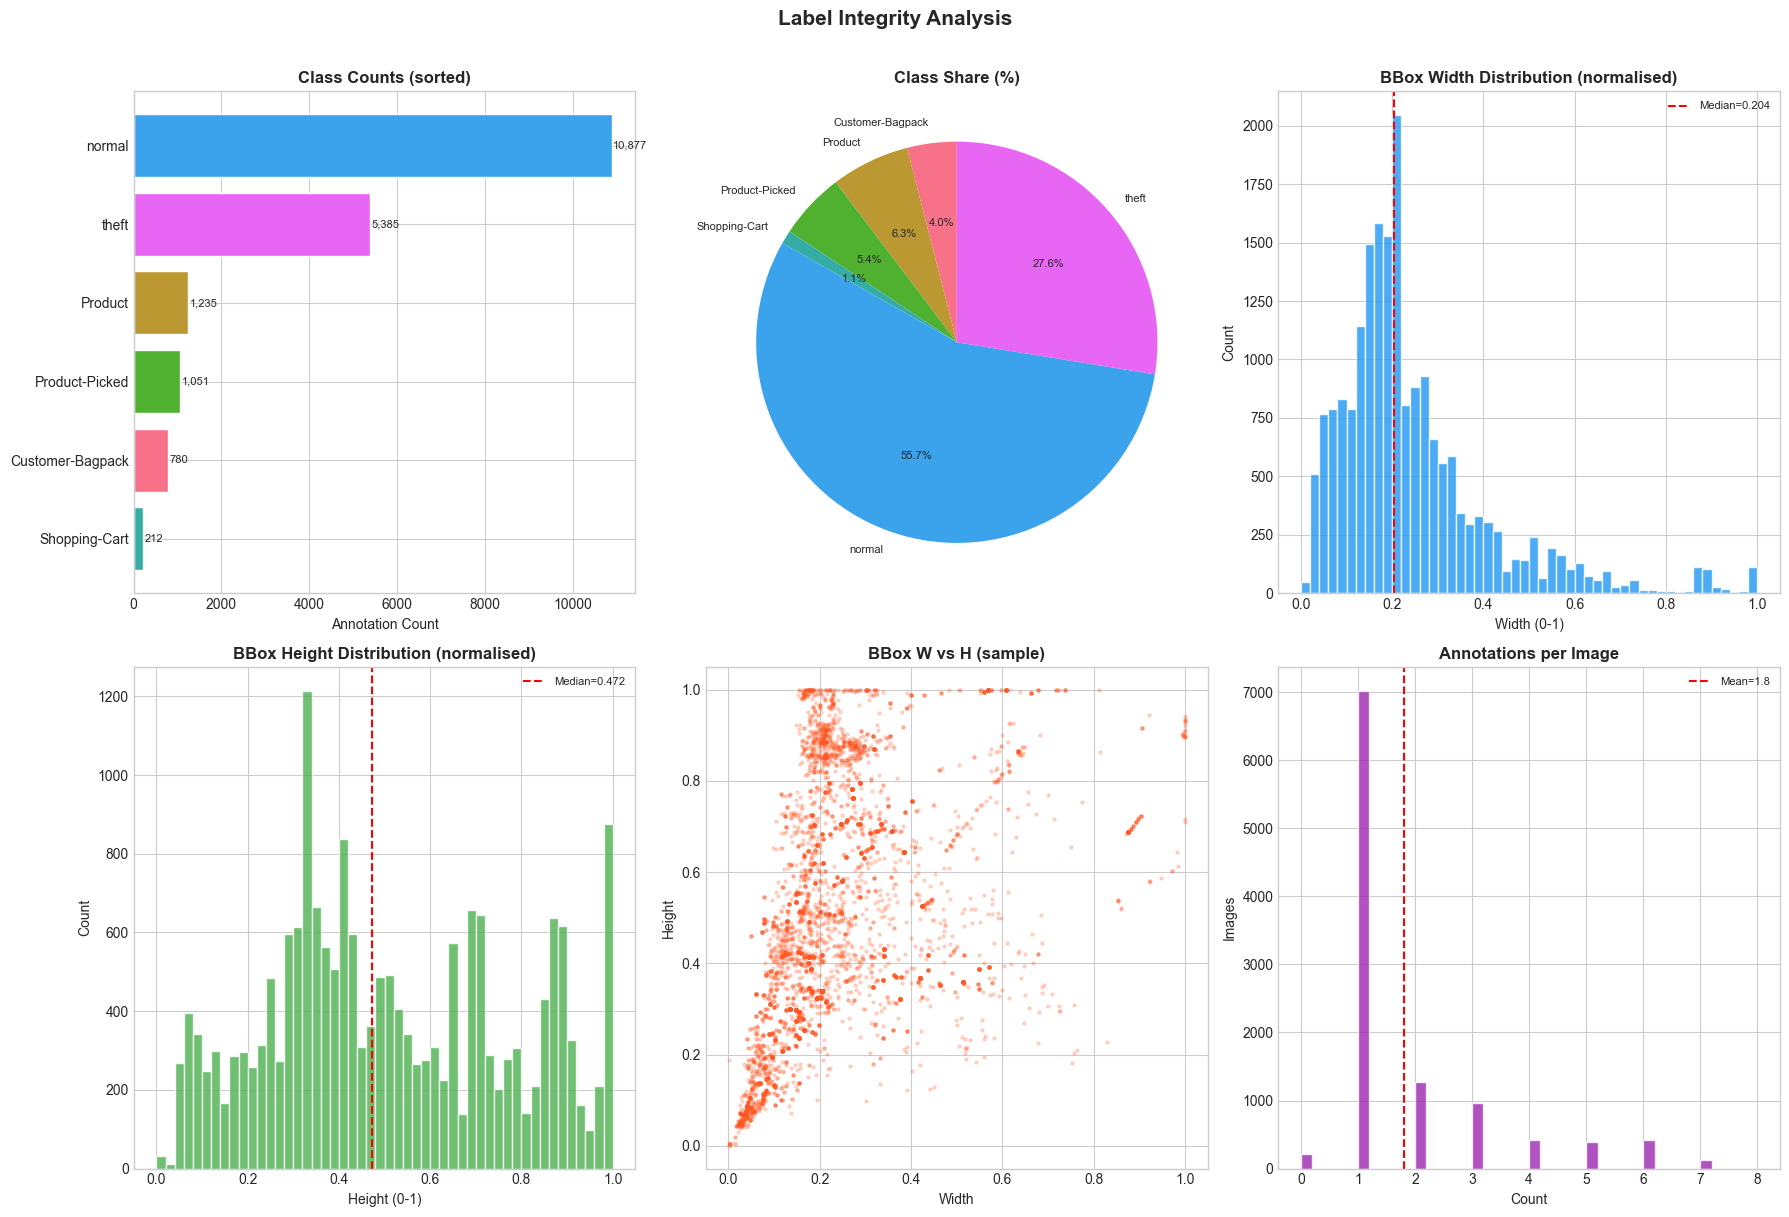

Chart saved → logs\03_integrity_analysis.png


In [9]:
fig = plt.figure(figsize=(18, 12))
fig.suptitle('Label Integrity Analysis', fontsize=15, fontweight='bold', y=1.01)

PALETTE = sns.color_palette('husl', NUM_CLASSES)

# ── 1. Class distribution (horizontal bar) ──────────────────
ax1 = fig.add_subplot(2, 3, 1)
sorted_ids   = sorted(range(NUM_CLASSES), key=lambda i: global_class_counts.get(i, 0), reverse=True)
sorted_names = [CLASS_NAMES[i] for i in sorted_ids]
sorted_vals  = [global_class_counts.get(i, 0) for i in sorted_ids]
ax1.barh(sorted_names, sorted_vals,
         color=[PALETTE[i] for i in sorted_ids], edgecolor='white')
ax1.set_title('Class Counts (sorted)', fontweight='bold')
ax1.set_xlabel('Annotation Count')
for i, v in enumerate(sorted_vals):
    ax1.text(v + total_anns * 0.002, i, f'{v:,}', va='center', fontsize=8)
ax1.invert_yaxis()

# ── 2. Class share pie chart ─────────────────────────────────
ax2 = fig.add_subplot(2, 3, 2)
pie_vals  = [global_class_counts.get(i, 0) for i in range(NUM_CLASSES)]
ax2.pie(pie_vals, labels=CLASS_NAMES, colors=PALETTE,
        autopct='%1.1f%%', startangle=90, textprops={'fontsize': 8})
ax2.set_title('Class Share (%)', fontweight='bold')

# ── 3. Bounding box width distribution ──────────────────────
ax3 = fig.add_subplot(2, 3, 3)
if all_bbox_widths:
    ax3.hist(all_bbox_widths, bins=50, color='#2196F3', alpha=0.8, edgecolor='white')
    ax3.axvline(np.median(all_bbox_widths), color='red', linestyle='--',
                linewidth=1.5, label=f'Median={np.median(all_bbox_widths):.3f}')
    ax3.set_title('BBox Width Distribution (normalised)', fontweight='bold')
    ax3.set_xlabel('Width (0-1)')
    ax3.set_ylabel('Count')
    ax3.legend(fontsize=8)

# ── 4. Bounding box height distribution ─────────────────────
ax4 = fig.add_subplot(2, 3, 4)
if all_bbox_heights:
    ax4.hist(all_bbox_heights, bins=50, color='#4CAF50', alpha=0.8, edgecolor='white')
    ax4.axvline(np.median(all_bbox_heights), color='red', linestyle='--',
                linewidth=1.5, label=f'Median={np.median(all_bbox_heights):.3f}')
    ax4.set_title('BBox Height Distribution (normalised)', fontweight='bold')
    ax4.set_xlabel('Height (0-1)')
    ax4.set_ylabel('Count')
    ax4.legend(fontsize=8)

# ── 5. BBox area scatter ─────────────────────────────────────
ax5 = fig.add_subplot(2, 3, 5)
if all_bbox_widths and all_bbox_heights:
    sample = min(5000, len(all_bbox_widths))
    idx    = np.random.choice(len(all_bbox_widths), sample, replace=False)
    ax5.scatter([all_bbox_widths[i] for i in idx],
                [all_bbox_heights[i] for i in idx],
                alpha=0.2, s=5, color='#FF5722')
    ax5.set_title('BBox W vs H (sample)', fontweight='bold')
    ax5.set_xlabel('Width')
    ax5.set_ylabel('Height')

# ── 6. Annotations per image histogram ──────────────────────
ax6 = fig.add_subplot(2, 3, 6)
if per_image_ann_counts:
    ax6.hist(per_image_ann_counts, bins=40, color='#9C27B0', alpha=0.8, edgecolor='white')
    ax6.axvline(np.mean(per_image_ann_counts), color='red', linestyle='--',
                linewidth=1.5, label=f'Mean={np.mean(per_image_ann_counts):.1f}')
    ax6.set_title('Annotations per Image', fontweight='bold')
    ax6.set_xlabel('Count')
    ax6.set_ylabel('Images')
    ax6.legend(fontsize=8)

plt.tight_layout()
out_path = LOG_DIR / '03_integrity_analysis.png'
plt.savefig(out_path, dpi=150, bbox_inches='tight')
plt.show()
print(f'Chart saved → {out_path}')

## Class Imbalance Analysis

In [10]:
total_anns = sum(global_class_counts.values())
counts_arr = np.array([global_class_counts.get(i, 0) for i in range(NUM_CLASSES)])
max_cnt    = counts_arr.max()

print('=' * 65)
print('CLASS IMBALANCE ANALYSIS')
print('=' * 65)
print(f'  Imbalance ratio (max / min): {max_cnt / max(counts_arr.min(), 1):.1f}x')
print(f'  Std deviation of counts    : {counts_arr.std():.0f}')

# Recommended augmentation multipliers for each class
target = max_cnt   # equalize to the dominant class
print(f'\n  Recommended augmentation to equalize all classes to {target:,}:')
print(f'  {"Class":<25} {"Current":>9} {"Target":>9} {"×Mult":>7}')
print('  ' + '-' * 54)
for cid in range(NUM_CLASSES):
    cnt  = global_class_counts.get(cid, 0)
    mult = target / cnt if cnt > 0 else float('inf')
    flag = '  ← needs augmentation' if mult > 1.5 else ''
    print(f'  {CLASS_NAMES[cid]:<25} {cnt:>9,} {target:>9,} {mult:>7.1f}x{flag}')

print()
print('NOTE: Theft class is the detection target — prioritise its quality')
print('      and consider mild over-sampling rather than extreme augmentation.')

CLASS IMBALANCE ANALYSIS
  Imbalance ratio (max / min): 51.3x
  Std deviation of counts    : 3807

  Recommended augmentation to equalize all classes to 10,877:
  Class                       Current    Target   ×Mult
  ------------------------------------------------------
  Customer-Bagpack                780    10,877    13.9x  ← needs augmentation
  Product                       1,235    10,877     8.8x  ← needs augmentation
  Product-Picked                1,051    10,877    10.3x  ← needs augmentation
  Shopping-Cart                   212    10,877    51.3x  ← needs augmentation
  normal                       10,877    10,877     1.0x
  theft                         5,385    10,877     2.0x  ← needs augmentation

NOTE: Theft class is the detection target — prioritise its quality
      and consider mild over-sampling rather than extreme augmentation.


## Save Integrity Report

In [11]:
bbox_stats = {}
if all_bbox_widths:
    bbox_stats = {
        'width':  {'mean': float(np.mean(all_bbox_widths)),
                   'median': float(np.median(all_bbox_widths)),
                   'std': float(np.std(all_bbox_widths))},
        'height': {'mean': float(np.mean(all_bbox_heights)),
                   'median': float(np.median(all_bbox_heights)),
                   'std': float(np.std(all_bbox_heights))},
        'area':   {'mean': float(np.mean(all_bbox_areas)),
                   'median': float(np.median(all_bbox_areas)),
                   'std': float(np.std(all_bbox_areas))},
    }

log_data = {
    'timestamp':            TIMESTAMP,
    'dataset':              str(DATASET_DIR.resolve()),
    'classes':              CLASS_NAMES,
    'orphan_images':        len(orphan_images),
    'orphan_labels':        len(orphan_labels),
    'orphan_labels_deleted':len(removed_orphan_labels),
    'empty_labels':         len(empty_labels),
    'high_annotation_images': len(high_ann_count),
    'split_integrity':      split_integrity,
    'global_class_counts':  {int(k): int(v) for k, v in global_class_counts.items()},
    'bbox_statistics':      bbox_stats,
    'per_image_ann_stats': {
        'mean':   float(np.mean(per_image_ann_counts)) if per_image_ann_counts else 0,
        'max':    int(np.max(per_image_ann_counts)) if per_image_ann_counts else 0,
        'median': float(np.median(per_image_ann_counts)) if per_image_ann_counts else 0,
    },
    'high_annotation_examples': high_ann_count[:20],
}

log_path = LOG_DIR / f'03_integrity_report_{TIMESTAMP}.json'
with open(log_path, 'w', encoding='utf-8') as f:
    json.dump(log_data, f, indent=2, default=str)

print(f'Report saved → {log_path}')
print()
print('=' * 50)
print('NOTEBOOK 03 COMPLETE')
print('Next: run  04_preprocessing_augmentation.ipynb')
print('=' * 50)

Report saved → logs\03_integrity_report_20260408_215338.json

NOTEBOOK 03 COMPLETE
Next: run  04_preprocessing_augmentation.ipynb
